# ECC Tensile Property Prediction: End-to-End Pipeline

**Forward pass** (predict Second Stress & Second Strain from mix composition)
**CQR intervals** (prediction uncertainty with coverage guarantees)
**SHAP analysis** (top 10 feature contributions to each target)
**Inverse design** (3-tier cost analysis: Budget / Standard / Premium, with price uncertainty bands)
**Monte Carlo validation** (honest reliability under batching error and model uncertainty)
**Worked examples** (input → output demo for forward and inverse, for faculty review)
**Hyperparameter tuning** (optional final step)

Data filter: drop rows with curing age explicitly under 28 days (extracted from `Specimen` and `Mixture` text). `Fiber Type` column dropped per supervisor instruction. `Shape Factor` is constant (0.733) and dropped.

## 1. Setup and Imports

In [2]:
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 120
np.random.seed(42)

## 2. Data Loading and Filtering

The raw dataset has 506 rows. We extract curing age from the free-text `Specimen` and `Mixture` columns using regex. Any row with an *explicitly* stated age under 28 days is dropped. Rows without an explicit age are kept (standard ECC literature convention is 28-day testing).

In [3]:
df_raw = pd.read_excel('../data/Tension Test_VIT_re.xlsx')

def extract_age(row):
    for col in ['Specimen', 'Mixture']:
        s = str(row[col]).lower() if pd.notna(row[col]) else ''
        m = re.search(r'(\d+)\s*[-]?\s*day', s)
        if m:
            return int(m.group(1))
    return None

df_raw['extracted_age'] = df_raw.apply(extract_age, axis=1)
mask_drop = (df_raw['extracted_age'].notna()) & (df_raw['extracted_age'] < 28)

print(f"Raw rows: {len(df_raw)}")
print(f"Rows with age < 28 days (dropped): {mask_drop.sum()}")
print(f"Age distribution of dropped rows:")
print(df_raw.loc[mask_drop, 'extracted_age'].value_counts().sort_index().to_string())

df = df_raw[~mask_drop].copy()
df = df.dropna(subset=['L/D', 'Fiber Volume']).reset_index(drop=True)
print(f"\nAfter filter + dropna(L/D, Fiber Volume): {len(df)} rows")

Raw rows: 659
Rows with age < 28 days (dropped): 37
Age distribution of dropped rows:
extracted_age
0.0      4
1.0      3
7.0      9
14.0    21

After filter + dropna(L/D, Fiber Volume): 621 rows


### 2.1 Target and feature split

Drop identifier columns (`Mixture`, `Specimen`), categorical `Fiber Type`, dead feature `Shape Factor`, and the extracted age helper.

In [4]:
drop_cols = ['Mixture', 'Specimen', 'Fiber Type', 'Shape Factor', 'extracted_age']
y_stress = df['Second Stress'].values
y_strain = df['Second Strain'].values

X_df = df.drop(columns=drop_cols + ['Second Stress', 'Second Strain']).copy()
X_df = X_df.fillna(0)

print(f"Raw features kept ({X_df.shape[1]}):")
for c in X_df.columns:
    print(f"  {c}")

print(f"\nTarget ranges:")
print(f"  Stress: {y_stress.min():.2f} - {y_stress.max():.2f} MPa (mean {y_stress.mean():.2f})")
print(f"  Strain: {y_strain.min()*100:.3f} - {y_strain.max()*100:.2f} % (mean {y_strain.mean()*100:.2f})")

Raw features kept (18):
  Fiber Volume
  Length (mm)
  Diameter (mm)
  L/D
  RI
  Cement
  Water
  Sand
  Fly ash C
  Fly ash F
  GGBS
  Coarse Aggr.
  Silica Fume
  Water Reducer / SP
  Fiber
  C/B
  W/C
  W/B

Target ranges:
  Stress: 0.86 - 11.06 MPa (mean 4.40)
  Strain: 0.007 - 13.46 % (mean 2.23)


## 3. Feature Engineering (37 total)

Four feature groups are added on top of the 18 raw features. The references are:

- **Data-driven ratios (8)** — standard composition ratios and presence indicators
- **UTRGV mix-design features (2)** — Fly Ash / Binder and Sand / Binder ratios (Park et al., 2020, Technical Report 0-7030-1)
- **Li (2003) micromechanics proxies (9)** — `sigma_cu`, `sigma_crack`, PSH strength, PSH energy, flaw-size proxy, fiber efficiency, tau proxy, J_b and J_tip. Direct τ₀ and flaw-size distribution are not available from mix proportions alone, so these are *proxies* (Li, V. C., 2003, *J. Advanced Concrete Technology* 1(3), 215-230).

In [5]:
binder = X_df['Cement'] + X_df['Fly ash F'] + X_df['Fly ash C'] + X_df['GGBS'] + X_df['Silica Fume']
paste = X_df['Cement'] + X_df['Water'] + X_df['Fly ash F'] + X_df['GGBS'] + X_df['Silica Fume'] + X_df['Fly ash C']

X_df['Paste_volume'] = paste
X_df['SCM_ratio'] = (X_df['Fly ash F'] + X_df['GGBS'] + X_df['Silica Fume'] + X_df['Fly ash C']) / (X_df['Cement'] + 1e-8)
X_df['Aggregate_ratio'] = (X_df['Sand'] + X_df['Coarse Aggr.']) / (paste + 1e-8)
X_df['Fiber_surface_area'] = X_df['Fiber Volume'] * X_df['Length (mm)'] / (X_df['Diameter (mm)'] + 1e-8)
X_df['FiberVol_x_LD'] = X_df['Fiber Volume'] * X_df['L/D']
X_df['has_GGBS'] = (X_df['GGBS'] > 0).astype(int)
X_df['has_CoarseAggr'] = (X_df['Coarse Aggr.'] > 0).astype(int)
X_df['has_SilicaFume'] = (X_df['Silica Fume'] > 0).astype(int)

X_df['FA_binder_ratio'] = (X_df['Fly ash F'] + X_df['Fly ash C']) / (binder + 1e-8)
X_df['S_B_ratio'] = X_df['Sand'] / (binder + 1e-8)

WB = X_df['W/B'].values + 1e-8
X_df['sigma_cu_proxy'] = X_df['Fiber Volume'].values * X_df['L/D'].values * (1.0 / WB)
X_df['sigma_crack_proxy'] = (binder.values / WB) / np.sqrt(
    (X_df['Sand'].values + X_df['Coarse Aggr.'].values) / (paste.values + 1e-8) + WB + 1e-8)
X_df['PSH_strength'] = X_df['sigma_cu_proxy'] / (X_df['sigma_crack_proxy'] + 1e-8)
X_df['Jb_complement'] = X_df['sigma_cu_proxy'] * (X_df['Length (mm)'].values / 2)
X_df['J_tip_proxy'] = X_df['sigma_crack_proxy'] ** 2
X_df['PSH_energy'] = X_df['Jb_complement'] / (X_df['J_tip_proxy'] + 1e-8)

d_f = X_df['Diameter (mm)'].values + 1e-8
L_f = X_df['Length (mm)'].values
V_f = X_df['Fiber Volume'].values
X_df['fiber_efficiency'] = (V_f / (np.pi * (d_f/2)**2 * L_f + 1e-8)) * L_f * np.pi * d_f
X_df['tau_proxy'] = 1.0 / WB
X_df['flaw_size_proxy'] = (X_df['Sand'].values + X_df['Coarse Aggr.'].values) / (paste.values + 1e-8) + WB

feature_names = list(X_df.columns)
X_arr = X_df.values
print(f"Total features: {X_arr.shape[1]}")
print(f"  Raw:              18")
print(f"  Data-driven:       8")
print(f"  UTRGV:             2")
print(f"  Li (2003) proxies: 9")

Total features: 37
  Raw:              18
  Data-driven:       8
  UTRGV:             2
  Li (2003) proxies: 9


### 3.1 Mix-group keys (for honest GroupKFold)

Replicate specimens of the same mix composition are grouped so that cross-validation never places replicates of one mix in both train and test folds. This gives the honest generalization metric — how the model performs on a *new* mix it has not seen before.

In [6]:
mix_cols = ['Cement', 'Water', 'Sand', 'Fly ash C', 'Fly ash F', 'GGBS',
            'Coarse Aggr.', 'Silica Fume', 'Water Reducer / SP', 'Fiber Volume', 'L/D']
group_keys = df[mix_cols].round(4).astype(str).agg(lambda r: '|'.join(r.astype(str)), axis=1)
groups = group_keys.factorize()[0]
print(f"Unique mix compositions: {len(np.unique(groups))}")
print(f"Rows per mix: mean={np.bincount(groups).mean():.2f}, median={np.median(np.bincount(groups)):.0f}, max={np.bincount(groups).max()}")

Unique mix compositions: 193
Rows per mix: mean=3.22, median=2, max=19


### 3.2 R² ceiling from replicate variability

The theoretical upper bound on R² is set by how much replicates of the same mix disagree. No model can predict better than the mix-mean. Reporting this ceiling puts our R² numbers in context.

In [7]:
mix_mean_strain = df.groupby(group_keys)['Second Strain'].transform('mean').values
mix_mean_stress = df.groupby(group_keys)['Second Stress'].transform('mean').values

ceil_strain = r2_score(y_strain, mix_mean_strain)
ceil_stress = r2_score(y_stress, mix_mean_stress)

print("R^2 CEILING (predicting mix-mean perfectly)")
print(f"  Stress: {ceil_stress:.4f}")
print(f"  Strain: {ceil_strain:.4f}")
print("\nAny R^2 we report should be read against these ceilings, not against 1.0.")

R^2 CEILING (predicting mix-mean perfectly)
  Stress: 0.9068
  Strain: 0.7849

Any R^2 we report should be read against these ceilings, not against 1.0.


## 4. Forward Pass — Model Training and Honest Evaluation

Two cross-validation schemes:

- **Random KFold (5-fold)** — standard sklearn setup, but replicates of the same mix can leak across folds, inflating R².
- **GroupKFold (5-fold)** — all replicates of a mix stay in one fold. This is the *honest* number for predicting a new, unseen mix.

Both are reported so the gap is transparent.

In [8]:
kf_rand = KFold(n_splits=5, shuffle=True, random_state=42)
kf_grp = GroupKFold(n_splits=5)

stress_model = lambda: ExtraTreesRegressor(n_estimators=500, max_depth=20, min_samples_leaf=2,
                                            max_features=1.0, random_state=42, n_jobs=-1)
strain_et = lambda: ExtraTreesRegressor(n_estimators=500, max_depth=15, min_samples_leaf=2,
                                         max_features='sqrt', random_state=42, n_jobs=-1)
strain_gbr = lambda: GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                                                subsample=0.85, loss='squared_error', random_state=42)

def metrics(y_true, y_pred, label, unit_mult=1, unit=''):
    r2 = r2_score(y_true, y_pred)
    sp = stats.spearmanr(y_true, y_pred)[0]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"  {label:30s} R2={r2:.4f}  Spearman={sp:.4f}  MAE={mae*unit_mult:.3f}{unit}  RMSE={rmse*unit_mult:.3f}{unit}")
    return r2, sp, mae, rmse

print("=" * 75)
print("STRESS (Extra Trees)")
print("=" * 75)
oof_stress_rand = cross_val_predict(stress_model(), X_arr, y_stress, cv=kf_rand)
m_stress_rand = metrics(y_stress, oof_stress_rand, "Random KFold", 1, ' MPa')
oof_stress_grp = cross_val_predict(stress_model(), X_arr, y_stress, cv=kf_grp, groups=groups)
m_stress_grp = metrics(y_stress, oof_stress_grp, "GroupKFold (honest)", 1, ' MPa')

print("\n" + "=" * 75)
print("STRAIN (ExtraTrees 0.7 + GBR 0.3 blend)")
print("=" * 75)
oof_et_rand = cross_val_predict(strain_et(), X_arr, y_strain, cv=kf_rand)
oof_gbr_rand = cross_val_predict(strain_gbr(), X_arr, y_strain, cv=kf_rand)
oof_strain_rand = 0.7 * oof_et_rand + 0.3 * oof_gbr_rand
m_strain_rand = metrics(y_strain, oof_strain_rand, "Random KFold", 100, ' %')

oof_et_grp = cross_val_predict(strain_et(), X_arr, y_strain, cv=kf_grp, groups=groups)
oof_gbr_grp = cross_val_predict(strain_gbr(), X_arr, y_strain, cv=kf_grp, groups=groups)
oof_strain_grp = 0.7 * oof_et_grp + 0.3 * oof_gbr_grp
m_strain_grp = metrics(y_strain, oof_strain_grp, "GroupKFold (honest)", 100, ' %')

r2_s, _, _, rmse_s = m_stress_rand
r2_e, _, _, rmse_e = m_strain_rand

STRESS (Extra Trees)
  Random KFold                   R2=0.8313  Spearman=0.8722  MAE=0.451 MPa  RMSE=0.655 MPa
  GroupKFold (honest)            R2=0.6268  Spearman=0.7157  MAE=0.702 MPa  RMSE=0.974 MPa

STRAIN (ExtraTrees 0.7 + GBR 0.3 blend)
  Random KFold                   R2=0.5844  Spearman=0.7352  MAE=0.871 %  RMSE=1.294 %
  GroupKFold (honest)            R2=0.3350  Spearman=0.5633  MAE=1.190 %  RMSE=1.637 %


### 4.1 Predicted-vs-Actual scatter plots

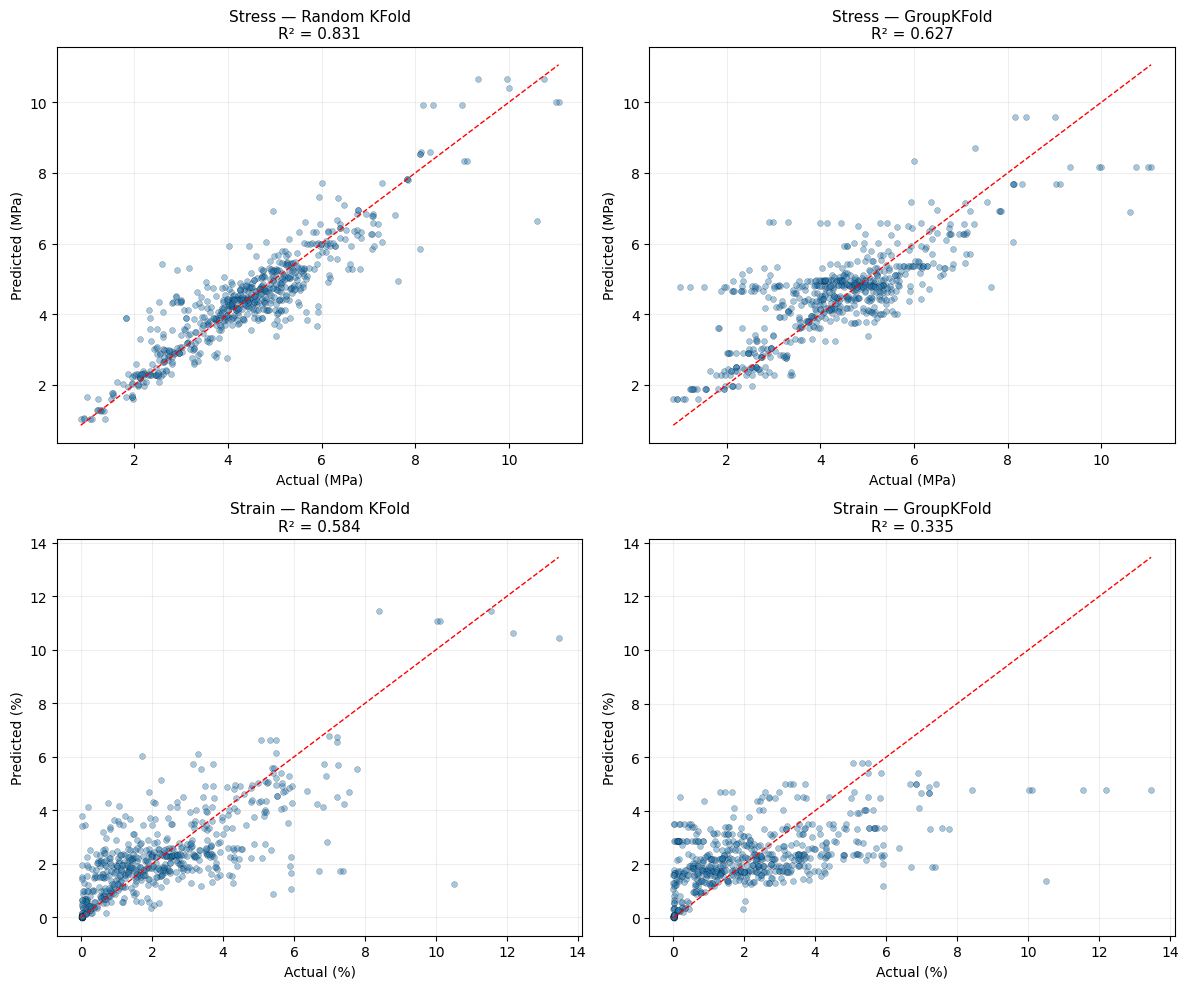

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, y_true, y_pred, title, unit_mult, unit in [
    (axes[0,0], y_stress, oof_stress_rand, 'Stress — Random KFold', 1, 'MPa'),
    (axes[0,1], y_stress, oof_stress_grp,  'Stress — GroupKFold',   1, 'MPa'),
    (axes[1,0], y_strain, oof_strain_rand, 'Strain — Random KFold', 100, '%'),
    (axes[1,1], y_strain, oof_strain_grp,  'Strain — GroupKFold',   100, '%'),
]:
    r2 = r2_score(y_true, y_pred)
    ax.scatter(y_true*unit_mult, y_pred*unit_mult, alpha=0.4, s=18, edgecolor='k', linewidth=0.3)
    lo, hi = min(y_true.min(), y_pred.min())*unit_mult, max(y_true.max(), y_pred.max())*unit_mult
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_xlabel(f'Actual ({unit})')
    ax.set_ylabel(f'Predicted ({unit})')
    ax.set_title(f'{title}\nR² = {r2:.3f}', fontsize=11)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 5. CQR Prediction Intervals

Conformalized Quantile Regression (CQR) wraps any model to produce calibrated prediction intervals. Instead of a single point estimate, we produce `[lo, hi]` such that the true value falls inside with the target coverage.

Key additions to a standard CQR report:

- **Coverage at multiple confidence levels** (50 %, 80 %, 90 %, 95 %) to check calibration
- **Per-quartile coverage** to see *where* the intervals are reliable
- **Relative interval width** (width / actual value) to judge practical usefulness
- **Comparison vs a naïve baseline** (mean ± 1.96·RMSE constant-width band)

In [10]:
def compute_cqr(X, y, kf_gen, alpha=0.20, cal_frac=0.25, random_state=42):
    n = len(X)
    oof_lo = np.full(n, np.nan)
    oof_hi = np.full(n, np.nan)
    oof_mid = np.full(n, np.nan)
    rng = np.random.RandomState(random_state)

    for tr_idx, te_idx in kf_gen:
        cs = int(len(tr_idx) * cal_frac)
        perm = rng.permutation(len(tr_idx))
        cal = tr_idx[perm[:cs]]
        fit = tr_idx[perm[cs:]]

        rf = RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_leaf=2,
                                    max_features=0.7, random_state=42, n_jobs=-1)
        rf.fit(X[fit], y[fit])

        lo_q = 100 * (alpha / 2)
        hi_q = 100 * (1 - alpha / 2)
        tp_cal = np.array([t.predict(X[cal]) for t in rf.estimators_])
        lo_c = np.percentile(tp_cal, lo_q, axis=0)
        hi_c = np.percentile(tp_cal, hi_q, axis=0)
        scores = np.maximum(lo_c - y[cal], y[cal] - hi_c)
        q = np.quantile(scores, 1 - alpha)

        tp_te = np.array([t.predict(X[te_idx]) for t in rf.estimators_])
        oof_lo[te_idx] = np.percentile(tp_te, lo_q, axis=0) - q
        oof_hi[te_idx] = np.percentile(tp_te, hi_q, axis=0) + q
        oof_mid[te_idx] = tp_te.mean(axis=0)
    return np.maximum(oof_lo, 0), oof_hi, oof_mid


alphas = [0.50, 0.20, 0.10, 0.05]
conf_levels = [1 - a for a in alphas]

cqr_stress = {}
cqr_strain = {}
for a in alphas:
    splits = list(kf_rand.split(X_arr))
    cqr_stress[a] = compute_cqr(X_arr, y_stress, splits, alpha=a)
    cqr_strain[a] = compute_cqr(X_arr, y_strain, splits, alpha=a)

print("CQR CALIBRATION TABLE")
print("-" * 75)
print(f"{'Conf Level':>12} {'Stress Cov':>12} {'Stress Width':>14} {'Strain Cov':>12} {'Strain Width':>14}")
for a in alphas:
    lo_s, hi_s, _ = cqr_stress[a]
    lo_e, hi_e, _ = cqr_strain[a]
    cov_s = ((y_stress >= lo_s) & (y_stress <= hi_s)).mean()
    cov_e = ((y_strain >= lo_e) & (y_strain <= hi_e)).mean()
    w_s = (hi_s - lo_s).mean()
    w_e = (hi_e - lo_e).mean() * 100
    print(f"{(1-a)*100:>11.0f}% {cov_s*100:>11.1f}% {w_s:>12.2f} MPa {cov_e*100:>11.1f}% {w_e:>12.2f} %")

print("\nWell-calibrated intervals have coverage ≈ confidence level.")

CQR CALIBRATION TABLE
---------------------------------------------------------------------------
  Conf Level   Stress Cov   Stress Width   Strain Cov   Strain Width
         50%        53.0%         0.82 MPa        47.8%         1.24 %
         80%        83.7%         1.75 MPa        77.6%         2.70 %
         90%        90.7%         2.37 MPa        88.2%         3.53 %
         95%        94.8%         3.03 MPa        93.1%         4.22 %

Well-calibrated intervals have coverage ≈ confidence level.


### 5.1 Coverage per performance quartile

A single coverage number hides *where* the intervals fail. We split the data into quartiles of the actual target and report coverage within each.

In [11]:
def per_quartile_coverage(y, lo, hi):
    qs = np.quantile(y, [0.25, 0.5, 0.75])
    rows = []
    for i, (a, b, lbl) in enumerate([
        (-np.inf, qs[0], 'Q1 (lowest)'),
        (qs[0], qs[1], 'Q2'),
        (qs[1], qs[2], 'Q3'),
        (qs[2], np.inf, 'Q4 (highest)'),
    ]):
        mask = (y >= a) & (y < b) if i < 3 else (y >= a)
        cov = ((y[mask] >= lo[mask]) & (y[mask] <= hi[mask])).mean() * 100
        w = (hi[mask] - lo[mask]).mean()
        rows.append((lbl, mask.sum(), cov, w))
    return rows

alpha_main = 0.20
lo_s, hi_s, _ = cqr_stress[alpha_main]
lo_e, hi_e, _ = cqr_strain[alpha_main]

print(f"PER-QUARTILE COVERAGE AT {int((1-alpha_main)*100)}% nominal\n")
print("STRESS:")
print(f"  {'Quartile':<15} {'N':>5} {'Coverage':>10} {'Width':>12}")
for lbl, n_, cov, w in per_quartile_coverage(y_stress, lo_s, hi_s):
    print(f"  {lbl:<15} {n_:>5} {cov:>9.1f}% {w:>9.2f} MPa")

print("\nSTRAIN:")
print(f"  {'Quartile':<15} {'N':>5} {'Coverage':>10} {'Width':>12}")
for lbl, n_, cov, w in per_quartile_coverage(y_strain, lo_e, hi_e):
    print(f"  {lbl:<15} {n_:>5} {cov:>9.1f}% {w*100:>10.2f} %")

PER-QUARTILE COVERAGE AT 80% nominal

STRESS:
  Quartile            N   Coverage        Width
  Q1 (lowest)       155      81.3%      1.44 MPa
  Q2                153      89.5%      1.68 MPa
  Q3                157      87.9%      1.75 MPa
  Q4 (highest)      156      76.3%      2.11 MPa

STRAIN:
  Quartile            N   Coverage        Width
  Q1 (lowest)       155      80.6%       1.71 %
  Q2                154      83.8%       2.91 %
  Q3                155      85.8%       2.66 %
  Q4 (highest)      157      60.5%       3.52 %


### 5.2 Visualization — sorted actual with interval band

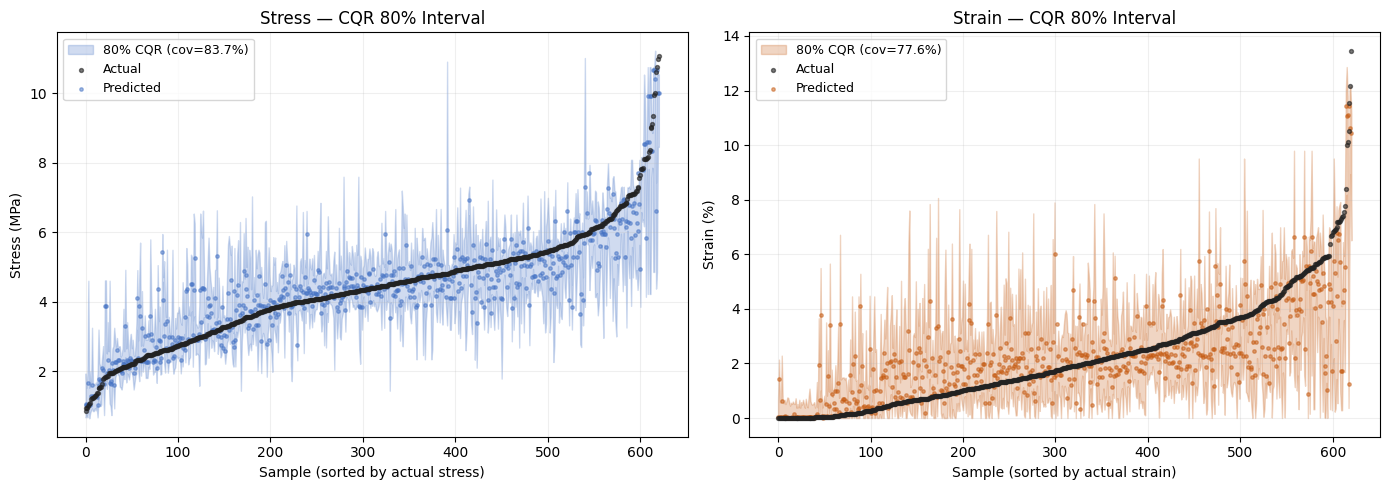

In [12]:
alpha_main = 0.20
lo_s, hi_s, mid_s = cqr_stress[alpha_main]
lo_e, hi_e, mid_e = cqr_strain[alpha_main]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_t, lo, hi, pred, title, unit_mult, unit, color in [
    (axes[0], y_stress, lo_s, hi_s, oof_stress_rand, "Stress", 1, "MPa", '#4472C4'),
    (axes[1], y_strain, lo_e, hi_e, oof_strain_rand, "Strain", 100, "%", '#C55A11'),
]:
    order = np.argsort(y_t)
    cov = ((y_t >= lo) & (y_t <= hi)).mean()
    n = len(y_t)
    ax.fill_between(range(n), lo[order]*unit_mult, hi[order]*unit_mult,
                     alpha=0.25, color=color, label=f'{int((1-alpha_main)*100)}% CQR (cov={cov*100:.1f}%)')
    ax.scatter(range(n), y_t[order]*unit_mult, s=8, c='#222', alpha=0.6, label='Actual', zorder=3)
    ax.scatter(range(n), pred[order]*unit_mult, s=6, c=color, alpha=0.5, label='Predicted', zorder=2)
    ax.set_xlabel(f'Sample (sorted by actual {title.lower()})')
    ax.set_ylabel(f'{title} ({unit})')
    ax.set_title(f'{title} — CQR {int((1-alpha_main)*100)}% Interval')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 5.3 CQR vs naïve constant-width baseline

A naïve "mean ± 1.96·RMSE" interval gives the same width everywhere. CQR should either match the naïve coverage at a narrower average width, or exceed its coverage at the same width. Otherwise CQR adds no value.

In [13]:
def naive_interval(y, pred, rmse, z=1.96):
    lo = pred - z * rmse
    hi = pred + z * rmse
    return lo, hi

print("CQR vs naive (mean ± 1.96·RMSE) at nominal 95%")
print("-" * 60)

for name, y_t, pred, rmse, cqr_alpha, mult, unit in [
    ("Stress", y_stress, oof_stress_rand, rmse_s, 0.05, 1, "MPa"),
    ("Strain", y_strain, oof_strain_rand, rmse_e, 0.05, 100, "%"),
]:
    nlo, nhi = naive_interval(y_t, pred, rmse)
    ncov = ((y_t >= nlo) & (y_t <= nhi)).mean() * 100
    nw = (nhi - nlo).mean() * mult
    lo, hi, _ = cqr_stress[cqr_alpha] if name == "Stress" else cqr_strain[cqr_alpha]
    ccov = ((y_t >= lo) & (y_t <= hi)).mean() * 100
    cw = (hi - lo).mean() * mult
    print(f"\n{name}:")
    print(f"  Naive    coverage={ncov:.1f}%  avg width={nw:.2f} {unit}")
    print(f"  CQR 95%  coverage={ccov:.1f}%  avg width={cw:.2f} {unit}")
    verdict = "tighter" if cw < nw else "wider"
    print(f"  CQR is {verdict} by {abs(nw-cw):.2f} {unit}")

CQR vs naive (mean ± 1.96·RMSE) at nominal 95%
------------------------------------------------------------

Stress:
  Naive    coverage=93.2%  avg width=2.57 MPa
  CQR 95%  coverage=94.8%  avg width=3.03 MPa
  CQR is wider by 0.46 MPa

Strain:
  Naive    coverage=93.9%  avg width=5.07 %
  CQR 95%  coverage=93.1%  avg width=4.22 %
  CQR is tighter by 0.86 %


## 6. Feature Effectiveness — Permutation Importance + Ablation

Two lenses:

- **Permutation importance** on the final model — shuffle each feature and measure R² drop. Ranks features by how much the trained model *actually uses* them.
- **Ablation study** — train models with progressive feature groups (raw → +data-driven → +UTRGV → +Li proxies → all). Shows the contribution of each group.

Running permutation importance (may take ~30s)...


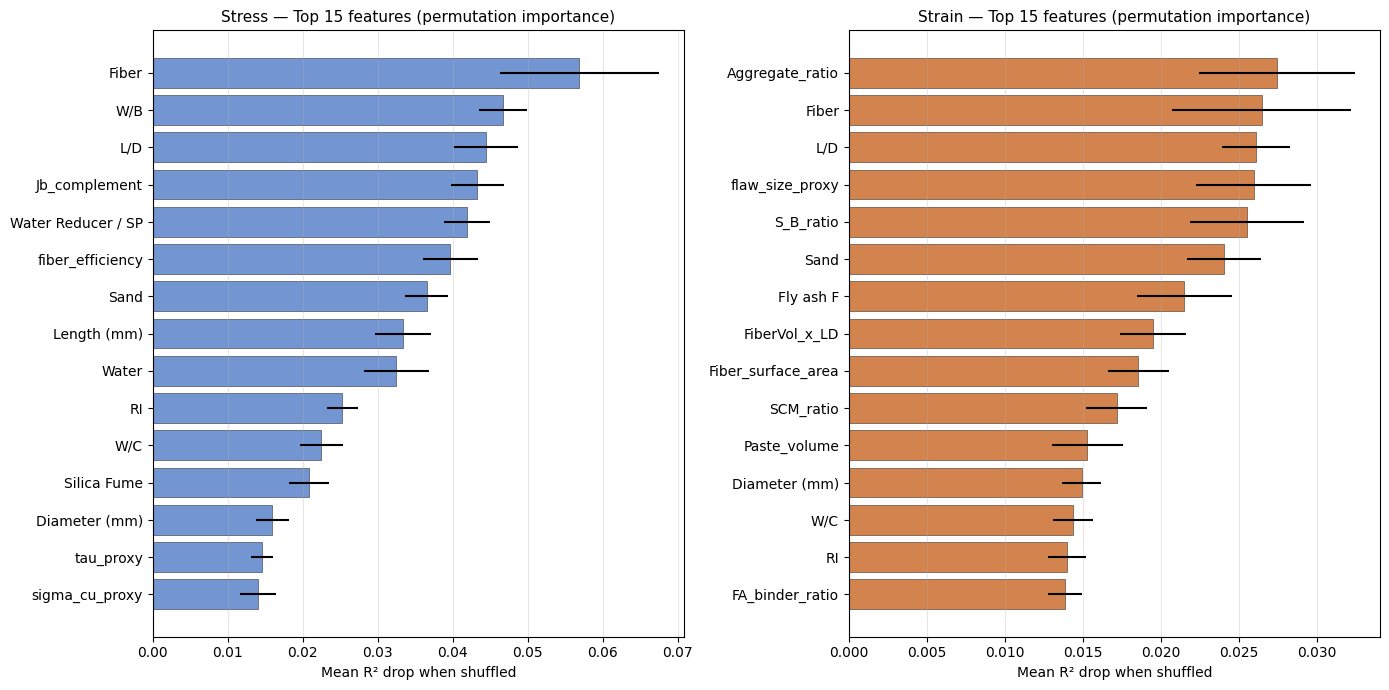


Top 5 for STRESS:
           feature  importance
             Fiber    0.056847
               W/B    0.046737
               L/D    0.044395
     Jb_complement    0.043287
Water Reducer / SP    0.041858

Top 5 for STRAIN:
        feature  importance
Aggregate_ratio    0.027404
          Fiber    0.026445
            L/D    0.026088
flaw_size_proxy    0.025940
      S_B_ratio    0.025509


In [14]:
m_stress_full = stress_model().fit(X_arr, y_stress)
m_strain_et_full = strain_et().fit(X_arr, y_strain)
m_strain_gbr_full = strain_gbr().fit(X_arr, y_strain)

print("Running permutation importance (may take ~30s)...")
pi_stress = permutation_importance(m_stress_full, X_arr, y_stress, n_repeats=10,
                                     random_state=42, n_jobs=-1, scoring='r2')
pi_et = permutation_importance(m_strain_et_full, X_arr, y_strain, n_repeats=10,
                                random_state=42, n_jobs=-1, scoring='r2')

imp_stress = pd.DataFrame({'feature': feature_names,
                            'importance': pi_stress.importances_mean,
                            'std': pi_stress.importances_std}).sort_values('importance', ascending=False)
imp_strain = pd.DataFrame({'feature': feature_names,
                            'importance': pi_et.importances_mean,
                            'std': pi_et.importances_std}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, imp, title, color in [
    (axes[0], imp_stress.head(15), 'Stress — Top 15 features (permutation importance)', '#4472C4'),
    (axes[1], imp_strain.head(15), 'Strain — Top 15 features (permutation importance)', '#C55A11'),
]:
    ax.barh(imp['feature'][::-1], imp['importance'][::-1], xerr=imp['std'][::-1],
            color=color, alpha=0.75, edgecolor='k', linewidth=0.4)
    ax.set_xlabel('Mean R² drop when shuffled')
    ax.set_title(title, fontsize=11)
    ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 for STRESS:")
print(imp_stress.head(5)[['feature','importance']].to_string(index=False))
print("\nTop 5 for STRAIN:")
print(imp_strain.head(5)[['feature','importance']].to_string(index=False))

### 6.1 Ablation — contribution of each feature group

We build four progressively larger feature sets and measure the R² gain from each addition. This directly answers *how effective were the UTRGV and Li-derived features?*

In [15]:
raw_cols = ['Fiber Volume', 'Length (mm)', 'Diameter (mm)', 'L/D', 'RI',
            'Cement', 'Water', 'Sand', 'Fly ash C', 'Fly ash F', 'GGBS',
            'Coarse Aggr.', 'Silica Fume', 'Water Reducer / SP', 'Fiber',
            'C/B', 'W/C', 'W/B']

data_driven_cols = ['Paste_volume', 'SCM_ratio', 'Aggregate_ratio', 'Fiber_surface_area',
                    'FiberVol_x_LD', 'has_GGBS', 'has_CoarseAggr', 'has_SilicaFume']
utrgv_cols = ['FA_binder_ratio', 'S_B_ratio']
li_cols = ['sigma_cu_proxy', 'sigma_crack_proxy', 'PSH_strength', 'Jb_complement',
           'J_tip_proxy', 'PSH_energy', 'fiber_efficiency', 'tau_proxy', 'flaw_size_proxy']

groups_def = [
    ("Raw only (18)",            raw_cols),
    ("+ Data-driven (26)",        raw_cols + data_driven_cols),
    ("+ UTRGV (28)",              raw_cols + data_driven_cols + utrgv_cols),
    ("+ Li proxies — ALL (37)",  raw_cols + data_driven_cols + utrgv_cols + li_cols),
]

def eval_feature_set(cols, y, is_strain=False):
    X_sub = X_df[cols].values
    if is_strain:
        oof_e = cross_val_predict(strain_et(), X_sub, y, cv=kf_rand)
        oof_g = cross_val_predict(strain_gbr(), X_sub, y, cv=kf_rand)
        oof = 0.7 * oof_e + 0.3 * oof_g
    else:
        oof = cross_val_predict(stress_model(), X_sub, y, cv=kf_rand)
    return r2_score(y, oof), stats.spearmanr(y, oof)[0]

print("ABLATION STUDY (Random KFold R²)")
print("=" * 70)
print(f"{'Feature set':<28} {'Stress R²':>10} {'Δ':>7} {'Strain R²':>10} {'Δ':>7}")
prev_s, prev_e = None, None
for name, cols in groups_def:
    r2s, _ = eval_feature_set(cols, y_stress, False)
    r2e, _ = eval_feature_set(cols, y_strain, True)
    ds = f"{r2s-prev_s:+.4f}" if prev_s is not None else "   —"
    de = f"{r2e-prev_e:+.4f}" if prev_e is not None else "   —"
    print(f"{name:<28} {r2s:>10.4f} {ds:>7} {r2e:>10.4f} {de:>7}")
    prev_s, prev_e = r2s, r2e

print("\nInterpretation: Δ column shows R² gain from adding that feature group.")

ABLATION STUDY (Random KFold R²)
Feature set                   Stress R²       Δ  Strain R²       Δ
Raw only (18)                    0.8381       —     0.5893       —
+ Data-driven (26)               0.8335 -0.0046     0.5960 +0.0068
+ UTRGV (28)                     0.8349 +0.0014     0.5935 -0.0025
+ Li proxies — ALL (37)          0.8313 -0.0036     0.5844 -0.0092

Interpretation: Δ column shows R² gain from adding that feature group.


## 7. SHAP — Top 10 Features per Target

SHAP (SHapley Additive exPlanations) decomposes each prediction into feature contributions. Unlike permutation importance, SHAP tells us the *direction* of effect — does a feature push predictions up or down, and at what values of that feature?

In [16]:
import shap

explainer_s = shap.TreeExplainer(m_stress_full)
explainer_e = shap.TreeExplainer(m_strain_et_full)

sample_idx = np.random.RandomState(42).choice(len(X_arr), size=min(300, len(X_arr)), replace=False)
X_sample = X_arr[sample_idx]

shap_values_s = explainer_s.shap_values(X_sample)
shap_values_e = explainer_e.shap_values(X_sample)

print("Generating SHAP summary plots (top 10 features each)...")

Generating SHAP summary plots (top 10 features each)...


### 7.1 SHAP summary — Stress

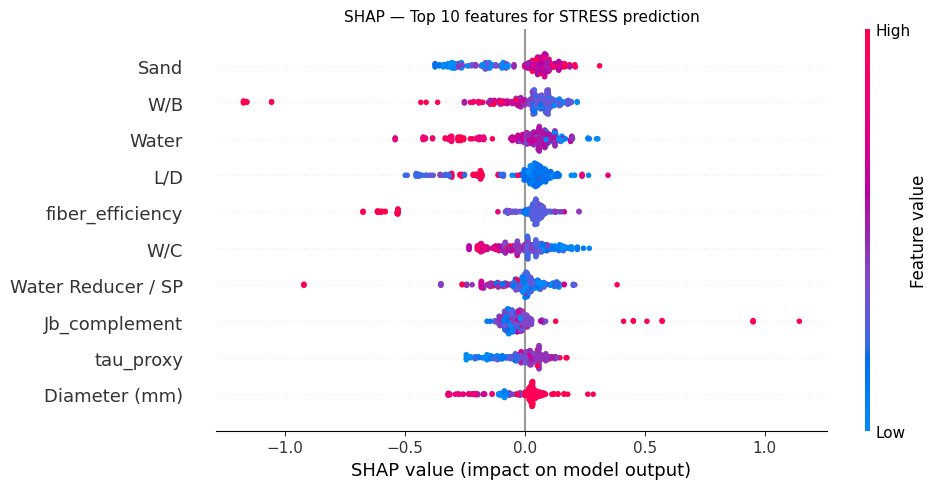


Top 10 features by mean |SHAP| for STRESS:
           feature  mean_abs_shap
              Sand       0.130194
               W/B       0.115231
             Water       0.110098
               L/D       0.107878
  fiber_efficiency       0.099023
               W/C       0.084193
Water Reducer / SP       0.073176
     Jb_complement       0.069907
         tau_proxy       0.065659
     Diameter (mm)       0.064926


In [17]:
shap.summary_plot(shap_values_s, X_sample, feature_names=feature_names,
                   max_display=10, show=False, plot_size=(10, 5))
plt.title('SHAP — Top 10 features for STRESS prediction', fontsize=11)
plt.tight_layout()
plt.show()

mean_abs_shap_s = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values_s).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
print("\nTop 10 features by mean |SHAP| for STRESS:")
print(mean_abs_shap_s.head(10).to_string(index=False))

### 7.2 SHAP summary — Strain

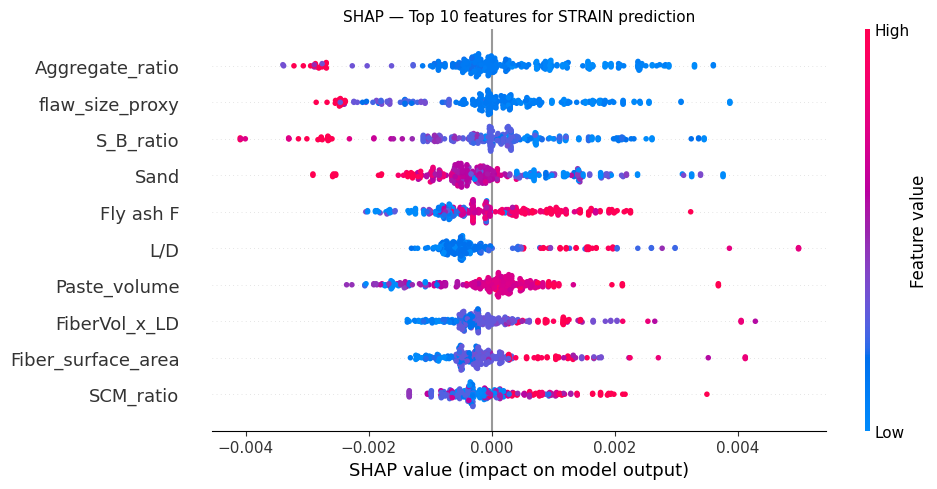


Top 10 features by mean |SHAP| for STRAIN:
           feature  mean_abs_shap
   Aggregate_ratio       0.000965
   flaw_size_proxy       0.000941
         S_B_ratio       0.000902
              Sand       0.000848
         Fly ash F       0.000790
               L/D       0.000725
      Paste_volume       0.000652
     FiberVol_x_LD       0.000583
Fiber_surface_area       0.000565
         SCM_ratio       0.000560


In [18]:
shap.summary_plot(shap_values_e, X_sample, feature_names=feature_names,
                   max_display=10, show=False, plot_size=(10, 5))
plt.title('SHAP — Top 10 features for STRAIN prediction', fontsize=11)
plt.tight_layout()
plt.show()

mean_abs_shap_e = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values_e).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
print("\nTop 10 features by mean |SHAP| for STRAIN:")
print(mean_abs_shap_e.head(10).to_string(index=False))

## 8. Production Models (trained on full data)

Trained on 100% of the filtered data for use by the inverse design pipeline. RF models are kept in parallel for prediction intervals.

In [19]:
m_stress = ExtraTreesRegressor(n_estimators=500, max_depth=20, min_samples_leaf=2,
                                max_features=1.0, random_state=42, n_jobs=-1).fit(X_arr, y_stress)
m_strain_et_prod = ExtraTreesRegressor(n_estimators=500, max_depth=15, min_samples_leaf=2,
                                        max_features='sqrt', random_state=42, n_jobs=-1).fit(X_arr, y_strain)
m_strain_gbr_prod = GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                                               subsample=0.85, random_state=42).fit(X_arr, y_strain)

m_rf_stress = RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_leaf=2,
                                     max_features=0.7, random_state=42, n_jobs=-1).fit(X_arr, y_stress)
m_rf_strain = RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_leaf=2,
                                     max_features=0.7, random_state=42, n_jobs=-1).fit(X_arr, y_strain)

print("Production models trained:")
print(f"  Stress: ExtraTrees (forward CV R² = {r2_s:.4f})")
print(f"  Strain: 0.7·ExtraTrees + 0.3·GBR (forward CV R² = {r2_e:.4f})")
print(f"  Intervals: RF (both targets)")

Production models trained:
  Stress: ExtraTrees (forward CV R² = 0.8313)
  Strain: 0.7·ExtraTrees + 0.3·GBR (forward CV R² = 0.5844)
  Intervals: RF (both targets)


## 9. Inverse Design — Cost Analysis with 3 Tiers

Rather than handing the engineer only the single cheapest mix, we return **three tiers** so they can pick based on budget and risk appetite:

- **Budget** — minimum cost mix that hits the target. Cheapest option, may sit near the edges of the performance target.
- **Standard** — balanced mix with the best *margin from target edges*. Most robust to batching errors; recommended default.
- **Premium** — highest predicted performance within the target range. Highest cost, best safety margin on upper bound.

**Cost uncertainty.** Material prices fluctuate with region, supplier, and market. Instead of a single-point cost, we propagate price uncertainty through Monte Carlo sampling and report a **90 % cost range**. Ingredient price uncertainties used:

| Category | Items | ± |
|---|---|---|
| Bulk commodity | Cement, Water, Sand, Fly ash C/F, Coarse Aggr. | ±10 % |
| Specialty | GGBS, Silica Fume, Water Reducer, Fiber | ±25 % |

Material reference prices (USD/kg):

| Ingredient | Cost | Ref |
|---|---|---|
| Cement | 0.30420 | [1] |
| Water | 0.00220 | [1] |
| Sand | 0.01980 | [1] |
| Fly ash C | 0.01349 | [2] |
| Fly ash F | 0.01349 | [2] |
| GGBS | 0.07860 | [2] |
| Coarse Aggregate | 0.02160 | [1] |
| Silica Fume | 0.39160 | [2] |
| Water Reducer / SP | 3.91600 | [2] |
| Fiber | 4.00000 | [3] |

### 9.1 Shared infrastructure — feature builder, prices, cost uncertainty

In [20]:
prices = {
    'Cement': 0.30420, 'Water': 0.00220, 'Sand': 0.01980,
    'Fly ash C': 0.01349, 'Fly ash F': 0.01349,
    'GGBS': 0.07860, 'Coarse Aggr.': 0.02160,
    'Silica Fume': 0.39160, 'Water Reducer / SP': 3.91600,
}
FIBER_PRICE_USD_PER_KG = 4.00

price_uncertainty = {
    'Cement': 0.10, 'Water': 0.10, 'Sand': 0.10,
    'Fly ash C': 0.10, 'Fly ash F': 0.10, 'Coarse Aggr.': 0.10,
    'GGBS': 0.25, 'Silica Fume': 0.25, 'Water Reducer / SP': 0.25,
}
FIBER_PRICE_UNCERTAINTY = 0.25

mix_cols_opt = ['Cement', 'Water', 'Sand', 'Fly ash C', 'Fly ash F',
                'GGBS', 'Coarse Aggr.', 'Silica Fume', 'Water Reducer / SP']

mix_bounds = np.array([
    [150, 1000],
    [80, 500],
    [0, 1000],
    [0, 800],
    [0, 1000],
    [0, 800],
    [0, 1000],
    [0, 200],
    [0, 40],
], dtype=float)


def build_feature_batch(mixes, fiber_params):
    N = len(mixes)
    fv, lf, df_f, ld, ri, fk = fiber_params
    cem, wat, sand, fa_c, fa_f = mixes[:,0], mixes[:,1], mixes[:,2], mixes[:,3], mixes[:,4]
    ggbs, ca, sf, sp = mixes[:,5], mixes[:,6], mixes[:,7], mixes[:,8]

    bnd = cem + fa_f + fa_c + ggbs + sf
    bnd_s = np.maximum(bnd, 50)
    wb = wat / bnd_s
    cb = cem / bnd_s
    wc = wat / (cem + 1e-8)
    pst = cem + wat + fa_f + ggbs + sf + fa_c
    ar = (sand + ca) / (pst + 1e-8)
    scu = fv * ld * (1.0 / (wb + 1e-8))
    scr = (bnd_s / (wb + 1e-8)) / np.sqrt(ar + wb + 1e-8)

    X = np.column_stack([
        np.full(N, fv), np.full(N, lf), np.full(N, df_f), np.full(N, ld), np.full(N, ri),
        cem, wat, sand, fa_c, fa_f, ggbs, ca, sf, sp, np.full(N, fk),
        cb, wc, wb, pst,
        (fa_f + ggbs + sf + fa_c) / (cem + 1e-8), ar,
        np.full(N, fv * lf / (df_f + 1e-8)), np.full(N, fv * ld),
        (ggbs > 0).astype(float), (ca > 0).astype(float), (sf > 0).astype(float),
        (fa_f + fa_c) / (bnd_s + 1e-8), sand / (bnd_s + 1e-8),
        scu, scr, scu / (scr + 1e-8),
        scu * (lf / 2), scr ** 2, (scu * (lf / 2)) / (scr ** 2 + 1e-8),
        np.full(N, (fv / (np.pi * (df_f/2)**2 * lf + 1e-8)) * lf * np.pi * df_f),
        1.0 / (wb + 1e-8), ar + wb
    ])

    valid = (bnd >= 50) & (wb >= 0.05) & (wb <= 1.0) & (cem >= 100)
    return X, valid


price_vec = np.array([prices[c] for c in mix_cols_opt])
price_unc_vec = np.array([price_uncertainty[c] for c in mix_cols_opt])

def compute_costs(mixes, fiber_kg):
    return mixes @ price_vec + fiber_kg * FIBER_PRICE_USD_PER_KG


def compute_cost_range(mix_array, fiber_kg, n_sim=5000, ci=0.90):
    rng = np.random.RandomState(42)
    price_samples = rng.normal(
        loc=price_vec,
        scale=price_vec * price_unc_vec / 1.645,
        size=(n_sim, len(price_vec))
    )
    price_samples = np.maximum(price_samples, 0)
    mat_costs = price_samples @ mix_array

    fiber_price_samples = rng.normal(
        loc=FIBER_PRICE_USD_PER_KG,
        scale=FIBER_PRICE_USD_PER_KG * FIBER_PRICE_UNCERTAINTY / 1.645,
        size=n_sim
    )
    fiber_price_samples = np.maximum(fiber_price_samples, 0)
    total_costs = mat_costs + fiber_price_samples * fiber_kg

    lo_pct = (1 - ci) / 2 * 100
    hi_pct = (1 + ci) / 2 * 100
    return {
        'mean': total_costs.mean(),
        'median': np.median(total_costs),
        'lo': np.percentile(total_costs, lo_pct),
        'hi': np.percentile(total_costs, hi_pct),
        'std': total_costs.std(),
    }


def predict_batch(X_feat):
    stress = m_stress.predict(X_feat)
    strain = 0.7 * m_strain_et_prod.predict(X_feat) + 0.3 * m_strain_gbr_prod.predict(X_feat)
    return stress, strain

print("Inverse design infrastructure ready.")
print("  Point-cost function:     compute_costs()")
print("  Price-uncertainty range: compute_cost_range()")

Inverse design infrastructure ready.
  Point-cost function:     compute_costs()
  Price-uncertainty range: compute_cost_range()


### 9.2 Tiered inverse design — Budget / Standard / Premium

**Algorithm.** Phase 1 samples 100 000 random mixes, scores them, and keeps those satisfying the target. Phase 2 locally refines the cheapest 50. Phase 3 classifies the final pool into three tiers:

- **Budget** = minimum point cost
- **Standard** = among candidates in the cheaper half, pick the one with the largest *minimum margin* to either target edge — most robust to batching noise
- **Premium** = among candidates in the more expensive half, pick the one with highest predicted strain (upper-range performer)

In [21]:
def inverse_design_tiers(stress_range, strain_range_pct, fiber_params,
                          n_samples=100000, top_k=50, n_refine=200, verbose=True):
    s_min, s_max = stress_range
    e_min, e_max = strain_range_pct[0] / 100, strain_range_pct[1] / 100
    fiber_kg = fiber_params[5]

    if verbose: print(f"Phase 1: sampling {n_samples:,} mixes...")
    rng = np.random.RandomState(42)
    mixes = rng.uniform(mix_bounds[:, 0], mix_bounds[:, 1], size=(n_samples, 9))
    X_feat, valid = build_feature_batch(mixes, fiber_params)
    stress_p, strain_p = predict_batch(X_feat)
    cost = compute_costs(mixes, fiber_kg)

    ok = valid & (stress_p >= s_min) & (stress_p <= s_max) & (strain_p >= e_min) & (strain_p <= e_max)
    if verbose: print(f"  valid & on-target: {ok.sum()}")

    if ok.sum() == 0:
        return {}

    idx_sorted = np.where(ok)[0][np.argsort(cost[ok])]
    seeds = mixes[idx_sorted[:top_k]]

    if verbose: print(f"Phase 2: refining top {len(seeds)} candidates...")
    pool_mix, pool_cost, pool_stress, pool_strain = [], [], [], []

    for idx_ok in idx_sorted[:top_k]:
        pool_mix.append(mixes[idx_ok])
        pool_cost.append(cost[idx_ok])
        pool_stress.append(stress_p[idx_ok])
        pool_strain.append(strain_p[idx_ok])

    for seed in seeds:
        span = (mix_bounds[:,1] - mix_bounds[:,0]) * 0.10
        perturb = rng.normal(0, 1, size=(n_refine, 9)) * span
        pert = np.clip(seed + perturb, mix_bounds[:,0], mix_bounds[:,1])
        Xp, vp = build_feature_batch(pert, fiber_params)
        sp, ep = predict_batch(Xp)
        cp = compute_costs(pert, fiber_kg)
        okp = vp & (sp >= s_min) & (sp <= s_max) & (ep >= e_min) & (ep <= e_max)
        for i in np.where(okp)[0]:
            pool_mix.append(pert[i])
            pool_cost.append(cp[i])
            pool_stress.append(sp[i])
            pool_strain.append(ep[i])

    pool_mix = np.array(pool_mix)
    pool_cost = np.array(pool_cost)
    pool_stress = np.array(pool_stress)
    pool_strain = np.array(pool_strain)

    if len(pool_mix) == 0:
        return {}

    if verbose: print(f"Phase 3: tiering {len(pool_mix)} candidates...")

    idx_budget = int(np.argmin(pool_cost))

    margin_stress = np.minimum(pool_stress - s_min, s_max - pool_stress)
    margin_strain = np.minimum(pool_strain - e_min, e_max - pool_strain)
    margin_min = np.minimum(margin_stress / max(s_max - s_min, 1e-8),
                             margin_strain / max(e_max - e_min, 1e-8))
    cost_median = np.median(pool_cost)
    cheap_half_mask = pool_cost <= cost_median
    if cheap_half_mask.sum() > 0:
        margin_sub = np.where(cheap_half_mask, margin_min, -np.inf)
        idx_standard = int(np.argmax(margin_sub))
    else:
        idx_standard = int(np.argmax(margin_min))

    exp_half_mask = pool_cost > cost_median
    if exp_half_mask.sum() > 0:
        strain_sub = np.where(exp_half_mask, pool_strain, -np.inf)
        idx_premium = int(np.argmax(strain_sub))
    else:
        idx_premium = int(np.argmax(pool_strain))

    def pack(idx, label):
        mix = pool_mix[idx]
        s_val = pool_stress[idx]
        e_val = pool_strain[idx]
        cr = compute_cost_range(mix, fiber_kg)
        X_f, _ = build_feature_batch(mix.reshape(1, -1), fiber_params)
        tp_s = np.array([t.predict(X_f)[0] for t in m_rf_stress.estimators_])
        tp_e = np.array([t.predict(X_f)[0] for t in m_rf_strain.estimators_])
        return {
            'tier': label,
            'mix': {k: round(float(v), 1) for k, v in zip(mix_cols_opt, mix)},
            'cost_point_usd_per_m3': round(float(pool_cost[idx]), 2),
            'cost_90ci_low': round(float(cr['lo']), 2),
            'cost_90ci_high': round(float(cr['hi']), 2),
            'cost_mean': round(float(cr['mean']), 2),
            'cost_std': round(float(cr['std']), 2),
            'pred_stress_MPa': round(float(s_val), 3),
            'pred_strain_pct': round(float(e_val) * 100, 3),
            'stress_90CI': (round(np.percentile(tp_s, 5), 2), round(np.percentile(tp_s, 95), 2)),
            'strain_90CI_pct': (round(np.percentile(tp_e, 5)*100, 2), round(np.percentile(tp_e, 95)*100, 2)),
        }

    return {
        'Budget':   pack(idx_budget,   'Budget'),
        'Standard': pack(idx_standard, 'Standard'),
        'Premium':  pack(idx_premium,  'Premium'),
    }


def print_tiers(tiers, target_stress, target_strain_pct):
    if not tiers:
        print("  No valid mixes found for the target range.")
        return
    print(f"\n{'='*78}")
    print(f"TIERED INVERSE DESIGN")
    print(f"  Target stress: {target_stress[0]}-{target_stress[1]} MPa")
    print(f"  Target strain: {target_strain_pct[0]}-{target_strain_pct[1]} %")
    print('='*78)

    tier_notes = {
        'Budget':   'Minimum cost — ideal when budget-constrained, may be less robust',
        'Standard': 'Most balanced margin — recommended default, robust to batching',
        'Premium':  'Highest predicted performance — best safety margin on upper bound',
    }

    for label in ['Budget', 'Standard', 'Premium']:
        c = tiers[label]
        print(f"\n>>> {label.upper():<9}  {tier_notes[label]}")
        print(f"    Cost (point):     ${c['cost_point_usd_per_m3']}/m³")
        print(f"    Cost (90% range): ${c['cost_90ci_low']} - ${c['cost_90ci_high']}/m³  (mean ${c['cost_mean']} ± {c['cost_std']})")
        print(f"    Predicted stress: {c['pred_stress_MPa']} MPa  (90% model CI: {c['stress_90CI']})")
        print(f"    Predicted strain: {c['pred_strain_pct']} %  (90% model CI: {c['strain_90CI_pct']})")
        print(f"    Mix (kg/m³):")
        for k, v in c['mix'].items():
            if v > 0.5:
                print(f"      {k:<22} {v:>8.1f}")

print("Tiered inverse-design functions defined.")

Tiered inverse-design functions defined.


### 9.3 Run the tiered inverse design

In [22]:
TARGET_STRESS = (3.0, 6.0)
TARGET_STRAIN = (2.0, 5.0)

PVA_FIBER = (0.02, 12.0, 0.039, 307.69, 6.15, 26.0)

tiers = inverse_design_tiers(TARGET_STRESS, TARGET_STRAIN, PVA_FIBER)
print_tiers(tiers, TARGET_STRESS, TARGET_STRAIN)

Phase 1: sampling 100,000 mixes...
  valid & on-target: 70917
Phase 2: refining top 50 candidates...
Phase 3: tiering 8367 candidates...

TIERED INVERSE DESIGN
  Target stress: 3.0-6.0 MPa
  Target strain: 2.0-5.0 %

>>> BUDGET     Minimum cost — ideal when budget-constrained, may be less robust
    Cost (point):     $168.24/m³
    Cost (90% range): $141.45 - $194.7/m³  (mean $168.21 ± 16.1)
    Predicted stress: 4.363 MPa  (90% model CI: (np.float64(2.19), np.float64(5.34)))
    Predicted strain: 2.408 %  (90% model CI: (np.float64(0.27), np.float64(5.48)))
    Mix (kg/m³):
      Cement                    150.0
      Water                     247.6
      Sand                       31.8
      Fly ash C                 407.3
      Fly ash F                 246.4
      GGBS                       69.8
      Water Reducer / SP          0.8

>>> STANDARD   Most balanced margin — recommended default, robust to batching
    Cost (point):     $214.14/m³
    Cost (90% range): $187.04 - $241.08/

### 9.4 Cost-range visualization across tiers

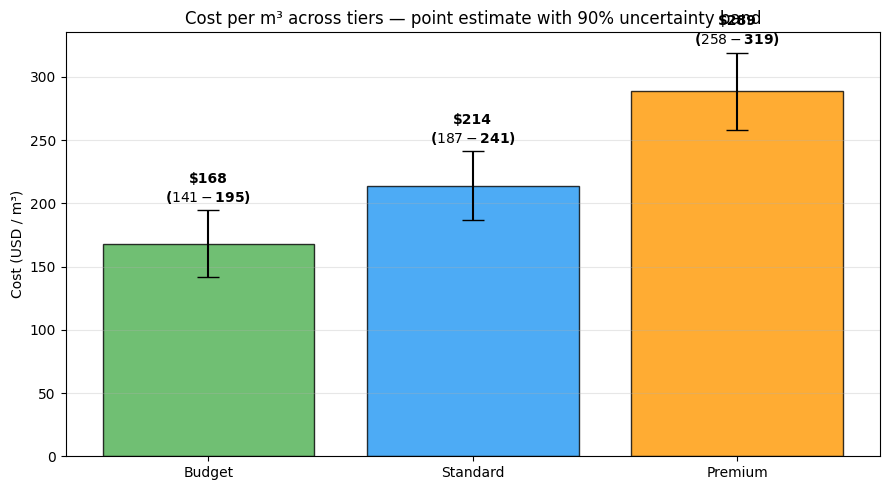

In [23]:
if tiers:
    labels = ['Budget', 'Standard', 'Premium']
    means = [tiers[l]['cost_mean'] for l in labels]
    los = [tiers[l]['cost_90ci_low'] for l in labels]
    his = [tiers[l]['cost_90ci_high'] for l in labels]
    err_lo = [m - l for m, l in zip(means, los)]
    err_hi = [h - m for m, h in zip(means, his)]

    colors = ['#4CAF50', '#2196F3', '#FF9800']
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(labels, means, yerr=[err_lo, err_hi], capsize=8,
                   color=colors, alpha=0.8, edgecolor='k', linewidth=1)
    for bar, m, l, h in zip(bars, means, los, his):
        ax.text(bar.get_x() + bar.get_width()/2, h + (max(his)-min(los))*0.02,
                 f'${m:.0f}\n(${l:.0f}-${h:.0f})',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cost (USD / m³)')
    ax.set_title('Cost per m³ across tiers — point estimate with 90% uncertainty band')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 10. Monte Carlo Validation — Honest Reliability

Given a recommended mix, simulate real-world uncertainty and estimate the probability that the built mix actually hits the target. Two noise sources:

- **Batching error** — a lab/plant can't hit target weights exactly. Typical 3–10 % per ingredient.
- **Model prediction uncertainty** — residual error between predicted and actual properties (from cross-validation RMSE).

Reporting *both* is what makes this "honest" — earlier analyses only considered batching.


Validating Standard-tier candidate (the recommended default)...

Monte Carlo Validation (3000 sims per error level)
Model RMSE: stress=0.655 MPa, strain=1.294%

 Batch err   Stress OK   Strain OK     Both OK      Verdict
------------------------------------------------------------
        3%       97.8%       75.4%       73.8%     MODERATE
        5%       97.8%       74.9%       73.2%     MODERATE
       10%       98.0%       75.3%       73.9%     MODERATE


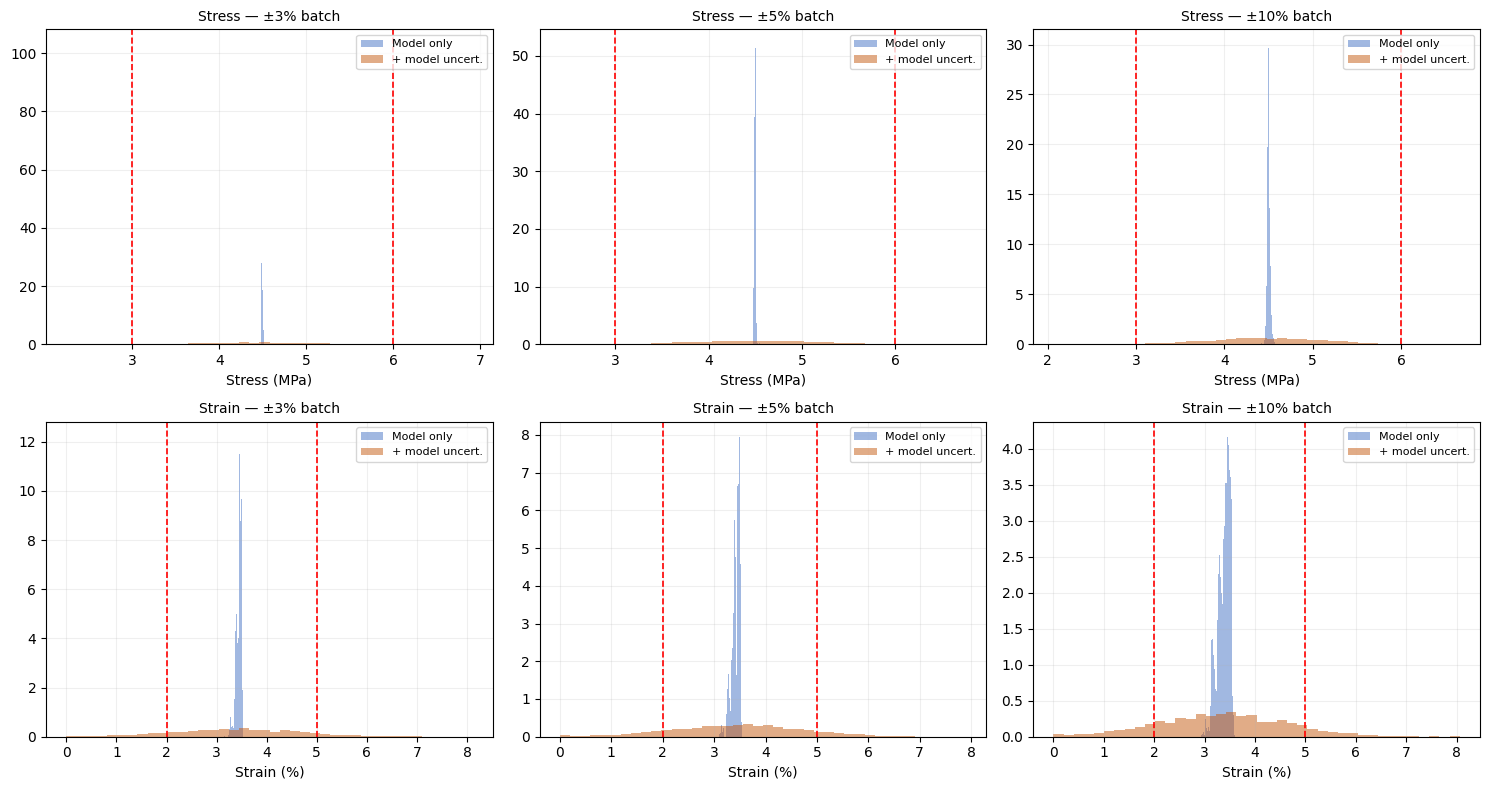

In [24]:
def monte_carlo_validate(recipe_mix_dict, fiber_params, target_stress, target_strain_pct,
                            n_sim=3000, error_margins=[0.03, 0.05, 0.10]):
    base = np.array([recipe_mix_dict[c] for c in mix_cols_opt])
    rng = np.random.RandomState(42)
    STRESS_RMSE = rmse_s
    STRAIN_RMSE = rmse_e

    fig, axes = plt.subplots(2, len(error_margins), figsize=(5*len(error_margins), 8))
    if len(error_margins) == 1:
        axes = axes.reshape(-1, 1)

    print(f"Monte Carlo Validation ({n_sim} sims per error level)")
    print(f"Model RMSE: stress={STRESS_RMSE:.3f} MPa, strain={STRAIN_RMSE*100:.3f}%")
    print(f"\n{'Batch err':>10} {'Stress OK':>11} {'Strain OK':>11} {'Both OK':>11} {'Verdict':>12}")
    print("-" * 60)

    for col, err in enumerate(error_margins):
        noise = rng.normal(1.0, err/3, size=(n_sim, 9))
        pert = np.maximum(base * noise, 0)
        X_b, _ = build_feature_batch(pert, fiber_params)
        ps, pe = predict_batch(X_b)
        rs = ps + rng.normal(0, STRESS_RMSE, n_sim)
        re_ = np.maximum(pe + rng.normal(0, STRAIN_RMSE, n_sim), 0)

        s_ok = ((rs >= target_stress[0]) & (rs <= target_stress[1])).mean() * 100
        e_ok = ((re_ >= target_strain_pct[0]/100) & (re_ <= target_strain_pct[1]/100)).mean() * 100
        b_ok = ((rs >= target_stress[0]) & (rs <= target_stress[1]) &
                (re_ >= target_strain_pct[0]/100) & (re_ <= target_strain_pct[1]/100)).mean() * 100
        verdict = "ROBUST" if b_ok >= 85 else "MODERATE" if b_ok >= 60 else "MARGINAL" if b_ok >= 40 else "UNSTABLE"
        print(f"{err*100:>9.0f}% {s_ok:>10.1f}% {e_ok:>10.1f}% {b_ok:>10.1f}% {verdict:>12}")

        ax = axes[0, col]
        ax.hist(ps, bins=40, alpha=0.5, color='#4472C4', label='Model only', density=True)
        ax.hist(rs, bins=40, alpha=0.5, color='#C55A11', label='+ model uncert.', density=True)
        ax.axvline(target_stress[0], color='red', ls='--', lw=1.2)
        ax.axvline(target_stress[1], color='red', ls='--', lw=1.2)
        ax.set_title(f'Stress — ±{err*100:.0f}% batch', fontsize=10)
        ax.set_xlabel('Stress (MPa)')
        ax.legend(fontsize=8); ax.grid(alpha=0.2)

        ax = axes[1, col]
        ax.hist(pe*100, bins=40, alpha=0.5, color='#4472C4', label='Model only', density=True)
        ax.hist(re_*100, bins=40, alpha=0.5, color='#C55A11', label='+ model uncert.', density=True)
        ax.axvline(target_strain_pct[0], color='red', ls='--', lw=1.2)
        ax.axvline(target_strain_pct[1], color='red', ls='--', lw=1.2)
        ax.set_title(f'Strain — ±{err*100:.0f}% batch', fontsize=10)
        ax.set_xlabel('Strain (%)')
        ax.legend(fontsize=8); ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


if tiers:
    print(f"\nValidating Standard-tier candidate (the recommended default)...\n")
    monte_carlo_validate(tiers['Standard']['mix'], PVA_FIBER, TARGET_STRESS, TARGET_STRAIN)

## 11. Summary Overview

A compact printout of the full pipeline's findings — useful for reports and mentor review.

In [25]:
print("="*78)
print("ECC TENSILE PROPERTY PIPELINE — SUMMARY")
print("="*78)
print(f"\nDATA")
print(f"  Raw rows:                  506")
print(f"  After age < 28d filter:    {len(df)}")
print(f"  Unique mix compositions:   {len(np.unique(groups))}")
print(f"  Features engineered:       {X_arr.shape[1]} (18 raw + 8 data-driven + 2 UTRGV + 9 Li)")

print(f"\nFORWARD MODEL PERFORMANCE")
print(f"  {'':30s} {'Random KFold':>14s} {'GroupKFold':>12s} {'Ceiling':>9s}")
print(f"  {'Stress (Extra Trees)':30s} {r2_score(y_stress, oof_stress_rand):>14.4f} {r2_score(y_stress, oof_stress_grp):>12.4f} {ceil_stress:>9.4f}")
print(f"  {'Strain (ET+GBR blend)':30s} {r2_score(y_strain, oof_strain_rand):>14.4f} {r2_score(y_strain, oof_strain_grp):>12.4f} {ceil_strain:>9.4f}")

print(f"\nCQR PREDICTION INTERVALS (80% nominal, Random KFold)")
lo_s80, hi_s80, _ = cqr_stress[0.20]
lo_e80, hi_e80, _ = cqr_strain[0.20]
print(f"  Stress: coverage={((y_stress>=lo_s80)&(y_stress<=hi_s80)).mean()*100:.1f}%  width={(hi_s80-lo_s80).mean():.2f} MPa")
print(f"  Strain: coverage={((y_strain>=lo_e80)&(y_strain<=hi_e80)).mean()*100:.1f}%  width={(hi_e80-lo_e80).mean()*100:.2f} %")

print(f"\nTOP 3 FEATURES")
print(f"  Stress: {', '.join(mean_abs_shap_s.head(3)['feature'].tolist())}")
print(f"  Strain: {', '.join(mean_abs_shap_e.head(3)['feature'].tolist())}")

print(f"\nINVERSE DESIGN (target: stress {TARGET_STRESS[0]}-{TARGET_STRESS[1]} MPa, strain {TARGET_STRAIN[0]}-{TARGET_STRAIN[1]} %)")
if tiers:
    for label in ['Budget', 'Standard', 'Premium']:
        t = tiers[label]
        print(f"  {label:<9}: ${t['cost_point_usd_per_m3']}/m³  (90% range ${t['cost_90ci_low']}-${t['cost_90ci_high']})  "
              f"stress={t['pred_stress_MPa']} MPa  strain={t['pred_strain_pct']}%")

print(f"\nKEY CAVEATS")
print(f"  - Random KFold overstates strain generalization by ~{r2_score(y_strain, oof_strain_rand) - r2_score(y_strain, oof_strain_grp):.2f} R².")
print(f"  - Strain ceiling from replicate noise is {ceil_strain:.3f}; gap to current R² is partly irreducible.")
print(f"  - Missing physics: direct τ₀ (interfacial bond), flaw distribution, curing condition not in features.")

ECC TENSILE PROPERTY PIPELINE — SUMMARY

DATA
  Raw rows:                  506
  After age < 28d filter:    621
  Unique mix compositions:   193
  Features engineered:       37 (18 raw + 8 data-driven + 2 UTRGV + 9 Li)

FORWARD MODEL PERFORMANCE
                                   Random KFold   GroupKFold   Ceiling
  Stress (Extra Trees)                   0.8313       0.6268    0.9068
  Strain (ET+GBR blend)                  0.5844       0.3350    0.7849

CQR PREDICTION INTERVALS (80% nominal, Random KFold)
  Stress: coverage=83.7%  width=1.75 MPa
  Strain: coverage=77.6%  width=2.70 %

TOP 3 FEATURES
  Stress: Sand, W/B, Water
  Strain: Aggregate_ratio, flaw_size_proxy, S_B_ratio

INVERSE DESIGN (target: stress 3.0-6.0 MPa, strain 2.0-5.0 %)
  Budget   : $168.24/m³  (90% range $141.45-$194.7)  stress=4.363 MPa  strain=2.408%
  Standard : $214.14/m³  (90% range $187.04-$241.08)  stress=4.498 MPa  strain=3.497%
  Premium  : $288.76/m³  (90% range $257.68-$319.31)  stress=5.075 MPa  stra

## 12. Worked Examples — Faculty Demo

This section demonstrates the complete input → output behaviour of both models with concrete example cases, exactly as the faculty would run them during a review.

### Example A — Forward Model

**Scenario:** A researcher has just designed a PVA-ECC mix and wants to know the predicted tensile behaviour before casting specimens in the lab.

**Input:** mix composition (kg/m³) + fiber parameters
**Output:** predicted Second Stress (MPa), Second Strain (%), with 90 % prediction intervals

### Example B — Inverse Model

**Scenario:** A structural engineer needs an ECC mix for a bridge-deck link slab that must sustain ≥ 2 % tensile strain while reaching 3–5 MPa in the post-cracking regime. They want to see budget/standard/premium options.

**Input:** target stress range, target strain range, fiber parameters
**Output:** three mix designs (Budget / Standard / Premium) with predicted performance, 90 % cost range, and 90 % model confidence intervals

### 12.1 Example A — Forward prediction on a user-specified mix

The helper wraps everything: engineered feature construction, blended strain prediction, and RF-based 90 % prediction intervals for both targets.

In [26]:
def predict_ecc_properties(mix_dict, fiber_params, verbose=True):
    mix_arr = np.array([[mix_dict[c] for c in mix_cols_opt]])
    X_feat, valid = build_feature_batch(mix_arr, fiber_params)

    if not valid[0]:
        print("WARNING: mix fails basic validity checks (binder too low, W/B out of range).")
        return None

    stress_pred = m_stress.predict(X_feat)[0]
    strain_pred = 0.7 * m_strain_et_prod.predict(X_feat)[0] + 0.3 * m_strain_gbr_prod.predict(X_feat)[0]

    tp_s = np.array([t.predict(X_feat)[0] for t in m_rf_stress.estimators_])
    tp_e = np.array([t.predict(X_feat)[0] for t in m_rf_strain.estimators_])
    stress_lo, stress_hi = np.percentile(tp_s, 5), np.percentile(tp_s, 95)
    strain_lo, strain_hi = np.percentile(tp_e, 5), np.percentile(tp_e, 95)

    fiber_kg = fiber_params[5]
    cr = compute_cost_range(mix_arr[0], fiber_kg)

    result = {
        'pred_stress_MPa': float(stress_pred),
        'stress_90CI': (float(stress_lo), float(stress_hi)),
        'pred_strain_pct': float(strain_pred) * 100,
        'strain_90CI_pct': (float(strain_lo)*100, float(strain_hi)*100),
        'cost_point_usd_per_m3': float(mix_arr[0] @ price_vec + fiber_kg * FIBER_PRICE_USD_PER_KG),
        'cost_90ci_low': float(cr['lo']),
        'cost_90ci_high': float(cr['hi']),
    }

    if verbose:
        print("="*70)
        print("FORWARD PREDICTION")
        print("="*70)
        print("\nInput mix (kg/m³):")
        for k, v in mix_dict.items():
            print(f"  {k:<22} {v:>8.1f}")
        print(f"\nFiber: Vf={fiber_params[0]*100:.1f}%, L={fiber_params[1]}mm, "
              f"d={fiber_params[2]}mm, L/D={fiber_params[3]:.0f}, RI={fiber_params[4]}")
        print(f"\nOutput:")
        print(f"  Predicted STRESS: {result['pred_stress_MPa']:.3f} MPa  "
              f"(90% CI: {result['stress_90CI'][0]:.2f} – {result['stress_90CI'][1]:.2f} MPa)")
        print(f"  Predicted STRAIN: {result['pred_strain_pct']:.3f} %    "
              f"(90% CI: {result['strain_90CI_pct'][0]:.2f} – {result['strain_90CI_pct'][1]:.2f} %)")
        print(f"  Est. material cost: ${result['cost_point_usd_per_m3']:.2f}/m³  "
              f"(90% range: ${result['cost_90ci_low']:.2f} – ${result['cost_90ci_high']:.2f}/m³)")

    return result


example_mix = {
    'Cement':               583.0,
    'Water':                298.0,
    'Sand':                 467.0,
    'Fly ash C':              0.0,
    'Fly ash F':            700.0,
    'GGBS':                   0.0,
    'Coarse Aggr.':           0.0,
    'Silica Fume':            0.0,
    'Water Reducer / SP':     6.5,
}
example_fiber = (0.02, 12.0, 0.039, 307.69, 6.15, 26.0)

result_A = predict_ecc_properties(example_mix, example_fiber)

FORWARD PREDICTION

Input mix (kg/m³):
  Cement                    583.0
  Water                     298.0
  Sand                      467.0
  Fly ash C                   0.0
  Fly ash F                 700.0
  GGBS                        0.0
  Coarse Aggr.                0.0
  Silica Fume                 0.0
  Water Reducer / SP          6.5

Fiber: Vf=2.0%, L=12.0mm, d=0.039mm, L/D=308, RI=6.15

Output:
  Predicted STRESS: 5.065 MPa  (90% CI: 4.03 – 6.77 MPa)
  Predicted STRAIN: 2.052 %    (90% CI: 0.79 – 4.82 %)
  Est. material cost: $326.15/m³  (90% range: $294.05 – $357.89/m³)


### 12.2 Example B — Inverse design for a link-slab target

Engineer specifies the performance envelope; the pipeline returns three tiers.

In [27]:
link_slab_stress_target = (3.0, 5.0)
link_slab_strain_target = (2.0, 4.0)
link_slab_fiber = (0.02, 12.0, 0.039, 307.69, 6.15, 26.0)

print("="*70)
print("INVERSE DESIGN — Bridge-deck link slab application")
print("="*70)
print(f"\nInput:")
print(f"  Target stress: {link_slab_stress_target[0]} – {link_slab_stress_target[1]} MPa (post-cracking strength)")
print(f"  Target strain: {link_slab_strain_target[0]} – {link_slab_strain_target[1]} % (deformation capacity)")
print(f"  Fiber: PVA, Vf={link_slab_fiber[0]*100:.1f}%, L={link_slab_fiber[1]}mm, "
      f"d={link_slab_fiber[2]}mm, L/D={link_slab_fiber[3]:.0f}")

tiers_B = inverse_design_tiers(link_slab_stress_target, link_slab_strain_target, link_slab_fiber)
print_tiers(tiers_B, link_slab_stress_target, link_slab_strain_target)

INVERSE DESIGN — Bridge-deck link slab application

Input:
  Target stress: 3.0 – 5.0 MPa (post-cracking strength)
  Target strain: 2.0 – 4.0 % (deformation capacity)
  Fiber: PVA, Vf=2.0%, L=12.0mm, d=0.039mm, L/D=308
Phase 1: sampling 100,000 mixes...
  valid & on-target: 42131
Phase 2: refining top 50 candidates...
Phase 3: tiering 7830 candidates...

TIERED INVERSE DESIGN
  Target stress: 3.0-5.0 MPa
  Target strain: 2.0-4.0 %

>>> BUDGET     Minimum cost — ideal when budget-constrained, may be less robust
    Cost (point):     $168.24/m³
    Cost (90% range): $141.45 - $194.7/m³  (mean $168.21 ± 16.1)
    Predicted stress: 4.363 MPa  (90% model CI: (np.float64(2.19), np.float64(5.34)))
    Predicted strain: 2.408 %  (90% model CI: (np.float64(0.27), np.float64(5.48)))
    Mix (kg/m³):
      Cement                    150.0
      Water                     247.6
      Sand                       31.8
      Fly ash C                 407.3
      Fly ash F                 246.4
      GGB

### 12.3 Example B — visualising the three tiers

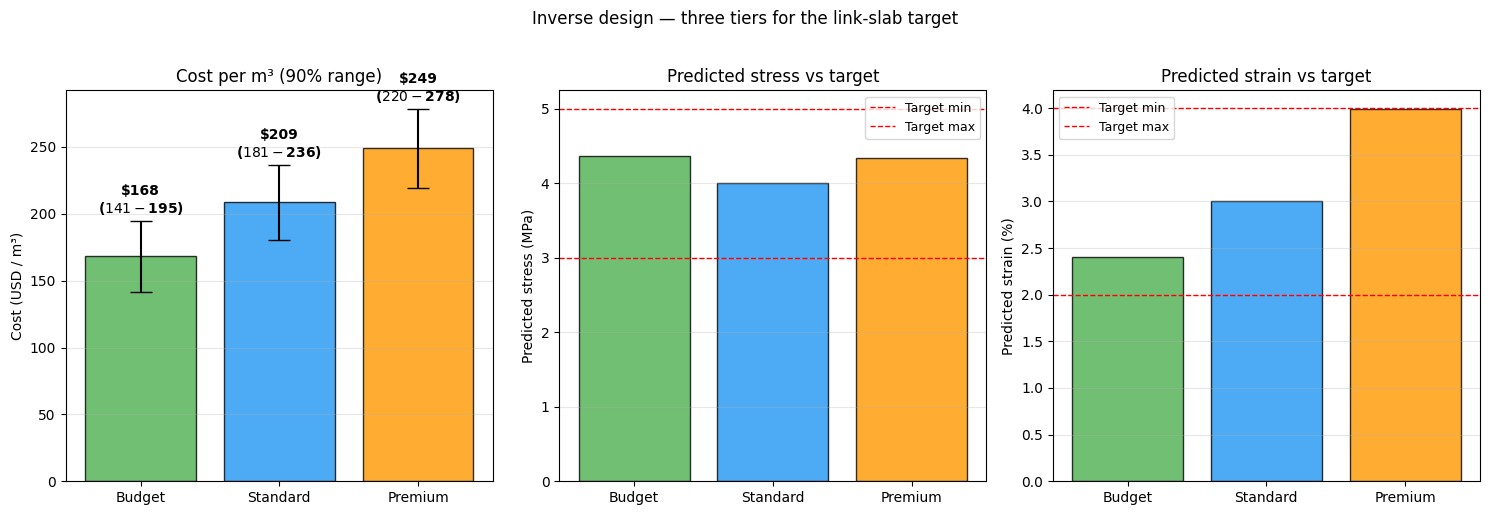

In [28]:
if tiers_B:
    labels = ['Budget', 'Standard', 'Premium']
    means = [tiers_B[l]['cost_mean'] for l in labels]
    los = [tiers_B[l]['cost_90ci_low'] for l in labels]
    his = [tiers_B[l]['cost_90ci_high'] for l in labels]
    err_lo = [m - l for m, l in zip(means, los)]
    err_hi = [h - m for m, h in zip(means, his)]
    stress_vals = [tiers_B[l]['pred_stress_MPa'] for l in labels]
    strain_vals = [tiers_B[l]['pred_strain_pct'] for l in labels]

    colors = ['#4CAF50', '#2196F3', '#FF9800']
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    ax = axes[0]
    bars = ax.bar(labels, means, yerr=[err_lo, err_hi], capsize=8,
                   color=colors, alpha=0.8, edgecolor='k', linewidth=1)
    for bar, m, l, h in zip(bars, means, los, his):
        ax.text(bar.get_x() + bar.get_width()/2, h + (max(his)-min(los))*0.02,
                 f'${m:.0f}\n(${l:.0f}-${h:.0f})',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cost (USD / m³)'); ax.set_title('Cost per m³ (90% range)')
    ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    ax.bar(labels, stress_vals, color=colors, alpha=0.8, edgecolor='k', linewidth=1)
    ax.axhline(link_slab_stress_target[0], color='red', ls='--', lw=1, label='Target min')
    ax.axhline(link_slab_stress_target[1], color='red', ls='--', lw=1, label='Target max')
    ax.set_ylabel('Predicted stress (MPa)'); ax.set_title('Predicted stress vs target')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    ax = axes[2]
    ax.bar(labels, strain_vals, color=colors, alpha=0.8, edgecolor='k', linewidth=1)
    ax.axhline(link_slab_strain_target[0], color='red', ls='--', lw=1, label='Target min')
    ax.axhline(link_slab_strain_target[1], color='red', ls='--', lw=1, label='Target max')
    ax.set_ylabel('Predicted strain (%)'); ax.set_title('Predicted strain vs target')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Inverse design — three tiers for the link-slab target', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

### 12.4 Example B — Monte Carlo validation on the recommended (Standard) mix

A final check: given batching noise and model uncertainty, how often does the recommended mix actually land inside the target box?

Monte Carlo validation of the STANDARD (recommended) mix

Monte Carlo Validation (3000 sims per error level)
Model RMSE: stress=0.655 MPa, strain=1.294%

 Batch err   Stress OK   Strain OK     Both OK      Verdict
------------------------------------------------------------
        3%       86.7%       55.6%       47.8%     MARGINAL
        5%       87.7%       56.1%       49.5%     MARGINAL
       10%       87.6%       54.9%       48.1%     MARGINAL


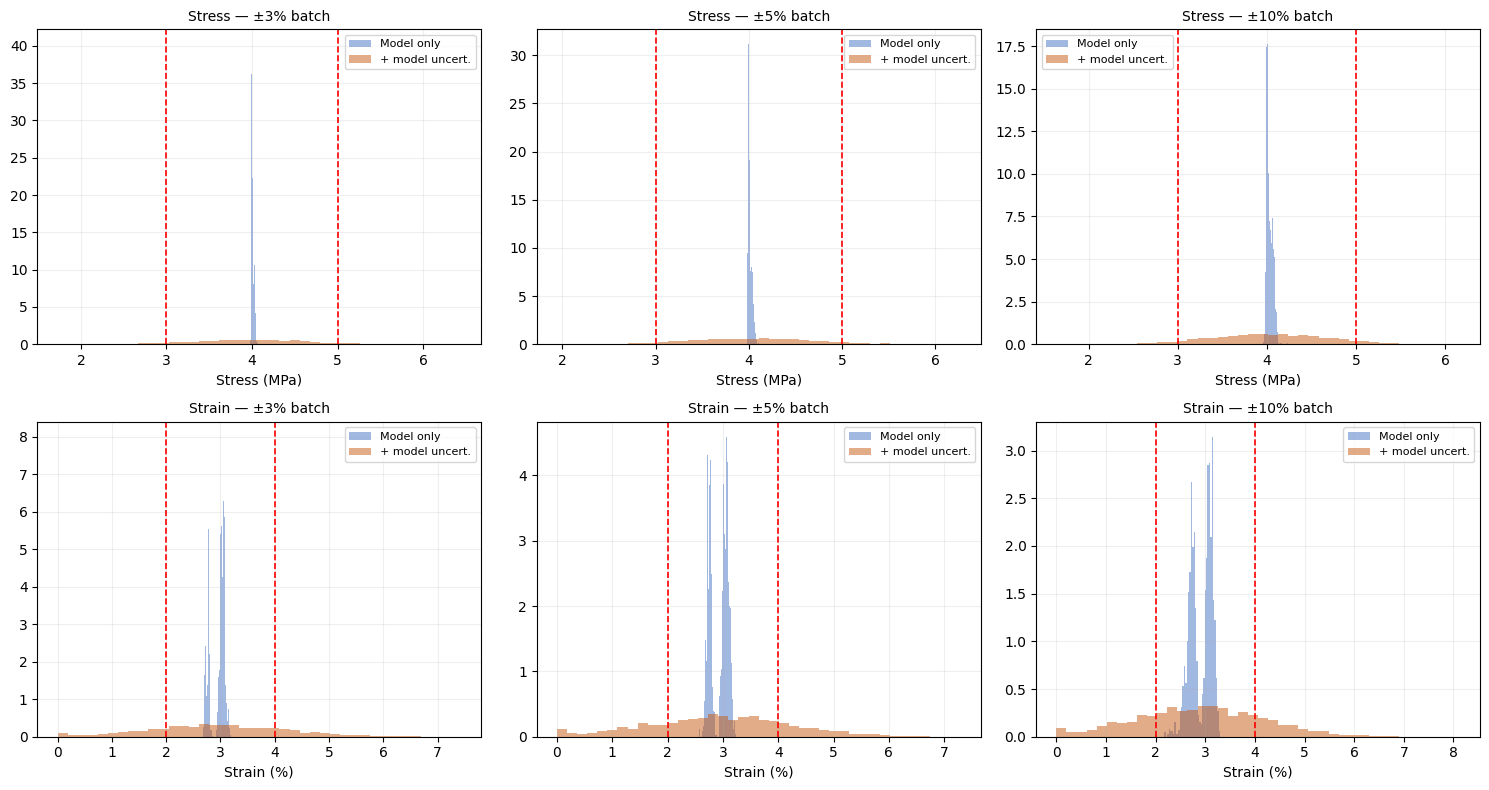

In [29]:
if tiers_B:
    print(f"Monte Carlo validation of the STANDARD (recommended) mix\n")
    monte_carlo_validate(tiers_B['Standard']['mix'], link_slab_fiber,
                          link_slab_stress_target, link_slab_strain_target)

## 13. Hyperparameter Tuning (Optional — run only if time permits)

Simple grid search over the most impactful hyperparameters for both models. Results are compared to the current baseline. Uses Random KFold for speed; can be switched to GroupKFold for honest evaluation.

In [30]:
from itertools import product

print("Grid searching STRESS (Extra Trees)...")
stress_grid = list(product(
    [300, 500, 800],
    [15, 20, None],
    [1, 2, 4],
    [1.0, 0.7, 'sqrt'],
))

best_s = (r2_score(y_stress, oof_stress_rand), None, None, None, None)
for n_est, md_, msl, mf in stress_grid:
    mdl = ExtraTreesRegressor(n_estimators=n_est, max_depth=md_, min_samples_leaf=msl,
                               max_features=mf, random_state=42, n_jobs=-1)
    oof = cross_val_predict(mdl, X_arr, y_stress, cv=kf_rand)
    r2 = r2_score(y_stress, oof)
    if r2 > best_s[0]:
        best_s = (r2, n_est, md_, msl, mf)

print(f"  Baseline: R²={r2_score(y_stress, oof_stress_rand):.4f}")
print(f"  Best:     R²={best_s[0]:.4f}  (n={best_s[1]}, depth={best_s[2]}, leaf={best_s[3]}, feat={best_s[4]})")

print("\nGrid searching STRAIN (ExtraTrees blend, varying ET params)...")
strain_grid = list(product(
    [300, 500, 800],
    [10, 15, 20],
    [1, 2, 4],
    ['sqrt', 0.5, 0.7, 1.0],
))

best_e = (r2_score(y_strain, oof_strain_rand), None, None, None, None)
for n_est, md_, msl, mf in strain_grid:
    mdl_et = ExtraTreesRegressor(n_estimators=n_est, max_depth=md_, min_samples_leaf=msl,
                                  max_features=mf, random_state=42, n_jobs=-1)
    oof_e = cross_val_predict(mdl_et, X_arr, y_strain, cv=kf_rand)
    blend = 0.7 * oof_e + 0.3 * oof_gbr_rand
    r2 = r2_score(y_strain, blend)
    if r2 > best_e[0]:
        best_e = (r2, n_est, md_, msl, mf)

print(f"  Baseline: R²={r2_score(y_strain, oof_strain_rand):.4f}")
print(f"  Best:     R²={best_e[0]:.4f}  (n={best_e[1]}, depth={best_e[2]}, leaf={best_e[3]}, feat={best_e[4]})")

Grid searching STRESS (Extra Trees)...
  Baseline: R²=0.8313
  Best:     R²=0.8323  (n=300, depth=15, leaf=2, feat=1.0)

Grid searching STRAIN (ExtraTrees blend, varying ET params)...
  Baseline: R²=0.5844
  Best:     R²=0.5844  (n=None, depth=None, leaf=None, feat=None)


---

### Usage notes

**To change the inverse-design target**
Edit `TARGET_STRESS` and `TARGET_STRAIN` in §9.3 (or `link_slab_*` in §12.2) and re-run.

**To switch fiber type**
Edit the fiber tuple `(Vf, L_mm, d_mm, L/D, RI, Fiber_kg_per_m³)`.

**To run the forward model on a new mix**
Fill `example_mix` in §12.1 and re-execute that cell — no retraining needed.

**To get honest generalization numbers only**
Comment out the Random KFold lines in §4 and §5 — keep only GroupKFold.

**To skip hyperparameter tuning**
Skip §13.